First importing the libraries as these libraries provide tools for data preprocessing, visualization, model training and evaluation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

Loading the Dataset csv fil  from Google Drive
head()? printing 1st 5 rows to understand structure of dataset

In [2]:
file_path = "/content/drive/MyDrive/heart_cleveland_upload.csv"
df = pd.read_csv(file_path)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


Statistical summary info help to understanding the dataset structure and detecting mssing values as well as identifying statistics before preprocessing

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        297 non-null    int64  
 1   sex        297 non-null    int64  
 2   cp         297 non-null    int64  
 3   trestbps   297 non-null    int64  
 4   chol       297 non-null    int64  
 5   fbs        297 non-null    int64  
 6   restecg    297 non-null    int64  
 7   thalach    297 non-null    int64  
 8   exang      297 non-null    int64  
 9   oldpeak    297 non-null    float64
 10  slope      297 non-null    int64  
 11  ca         297 non-null    int64  
 12  thal       297 non-null    int64  
 13  condition  297 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 32.6 KB


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,2.158249,131.693603,247.350168,0.144781,0.996633,149.599327,0.326599,1.055556,0.602694,0.676768,0.835017,0.461279
std,9.049736,0.468500,0.964859,17.762806,51.997583,0.352474,0.994914,22.941562,0.469761,1.166123,0.618187,0.938965,0.956690,0.499340
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,2.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,56.000000,1.000000,2.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,0.000000,0.000000
75%,61.000000,1.000000,3.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,1.000000,1.000000,2.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,2.000000,1.000000


Checing and handling missing values to ensure the data quality and avoid teh error during model training

In [4]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [5]:
df.fillna(df.mean(), inplace=True)

Exploratory Data Analysis (EDA)


6,1 Trget DIstribution
This will help to identify class imbalance
Based on output:
"
0    160
1    137
"
"0 mean no deseas, and 1 Mean desease"
The dataset is relatvly balanced with 160 negative and 137 positive cases

condition
0    160
1    137
Name: count, dtype: int64


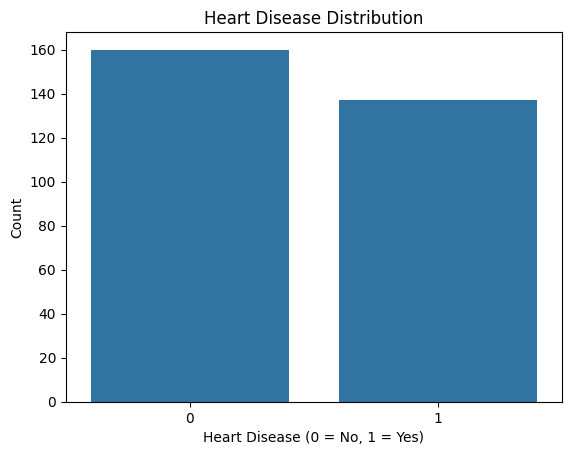

In [6]:
sns.countplot(x='condition', data=df)
plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Count")
print(df['condition'].value_counts())
plt.show()

6.2 Correlation analysis
This will help to understand how features influence each other and target variable

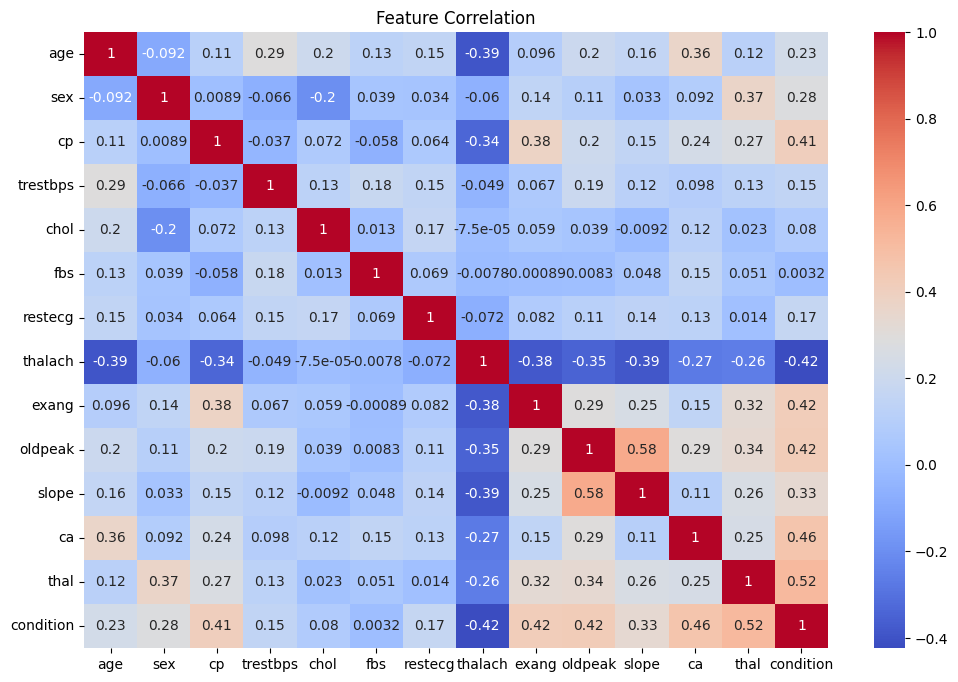

In [7]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

Split Data x,y
X contains the input features used for prediction and y is the target variable representing the presence or absence of heart disease.

In [8]:
X = df.drop('condition', axis=1)
y = df['condition']

Train (split & test data)

to Train on one part and test on another part (unseen data)
This ensures the model generalizes well and avoid overfitting

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Training Logistic Regression model and the probability of a binary outcome using a sigmoid function

In [10]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

Prediction and accuracy (accuracy=0.73 = 73%

In [11]:
y_pred = model.predict(X_test)

In [12]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7333333333333333


Confusion matrix
For detail performance beyond accuracy
"The model achieved 73.3% accuracy and the confusion matrix shows a reasonable balance between true positives and true negatives but there are some false negatives which are critical in medical diagnosis but false negatives are more important because missing a heart disease patient can have serious consequences

[[23  9]
 [ 7 21]]


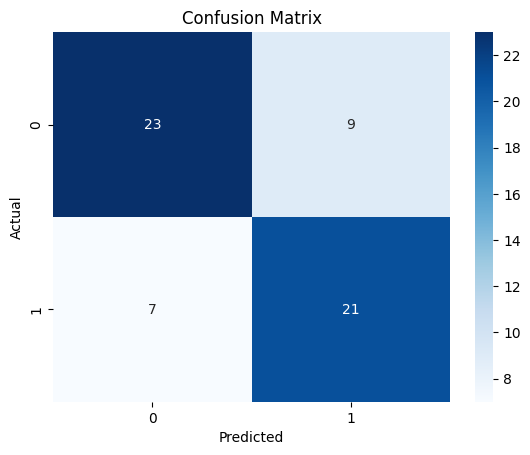

In [13]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

ROC Curve + AUC
AUC measures the model ability to distinguish between classes
"The ROC curve evaluates the models ability to distinguish between classes at different thresholds The AUC score of 0.828 indicates that the model performs well in separating patients with and without heart disease"

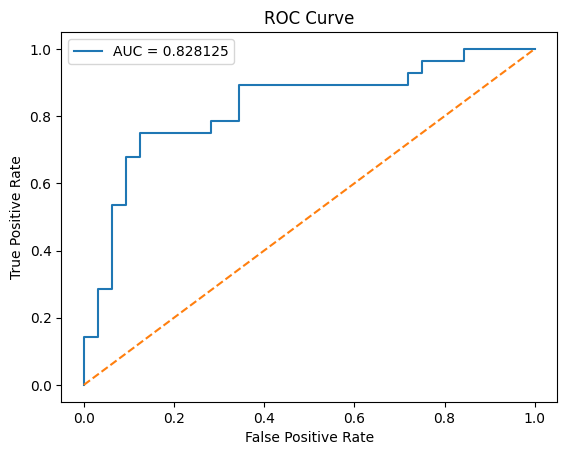

In [14]:
y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, label="AUC = " + str(auc))
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

Feature importance improves interpretability and helps identify key medical factors
"The feature importance grph shows that variables like ca, sex, and thal have the highest influnce on predicting heart disease
while features like age and cholesterol contribute less in this dataset

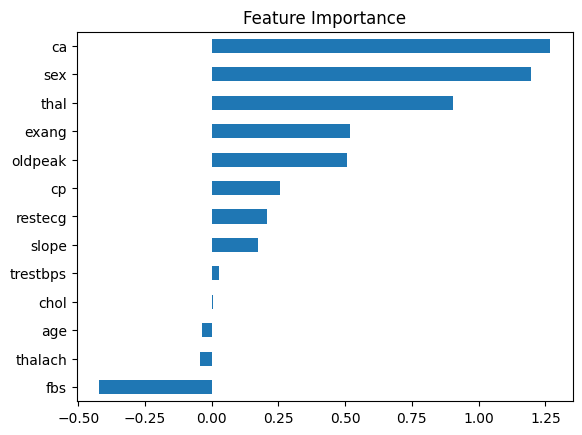

In [15]:
importance = pd.Series(model.coef_[0], index=X.columns)
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

_________________________________


Overal summary:
I built a complete ML pipeline in which i've done preprocesing, EDA, logistic regression model training, and evaluation using accuracy, confusion matrix, and ROC-AUC.
I also analyzed feature importance to interpret the model

Saving the model

In [16]:
import joblib

joblib.dump(model, "DHC-1898 task 3 model.pkl")

['DHC-1898 task 3 model.pkl']

In [17]:
joblib.dump(model, "/content/drive/MyDrive/DHC-1898 task 3 model.pkl")

['/content/drive/MyDrive/DHC-1898 task 3 model.pkl']

For loading the again the dataset, use the following below cell

In [ ]:
# Load model
loaded_model = joblib.load("/content/drive/MyDrive/DHC-1898 task 3 model.pkl")